In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 5, 6, 7, 8, 9, 10, 
years: 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 
years: 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.0,0.0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,55,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.0,0.0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,4,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.0,0.0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.0,0.0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,35,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.0,0.0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,41,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 5 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-05-01,αττικης,αγιας βαρβαρας,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.109613,-0.012625,-0.187337,0.012625,0.138277,-0.005005,-0.207972,0.005005,0.029821,0.009216,0.029016,0.009216,23.350000,30.490000,16.210000,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.259019,3.113871,298.432541,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,55,110,0
1,23.82642,38.00806,2010-05-01,αττικης,αγιας παρασκευης,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.246119,0.081537,-0.195054,-0.081537,0.233828,0.069670,-0.201405,-0.069670,0.021948,0.017464,0.011308,0.017464,21.690000,27.930000,15.450000,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.726824,4.312400,321.631232,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,4,8,0
2,23.73031,37.93357,2010-05-01,αττικης,αγιου δημητριου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124847,0.005892,-0.182192,-0.005892,0.125107,0.005422,-0.183339,-0.005422,0.009420,0.007833,0.003301,0.007833,22.480000,28.450000,16.510000,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.083028,2.944309,312.558510,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,1,2,0
3,23.71341,38.04721,2010-05-01,αττικης,αγιων αναργυρων καματερου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.216806,0.029374,-0.251409,-0.029374,0.229817,0.025588,-0.262820,-0.025588,0.021876,0.009936,0.015521,0.009936,23.250000,30.930000,15.570000,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.899900,5.003595,317.147450,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,35,70,0
4,23.34009,37.69503,2010-05-01,αττικης,αγκιστριου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.400133,0.081147,-0.245265,-0.081147,0.406088,0.079231,-0.261955,-0.079231,0.028368,0.042376,0.058683,0.042376,17.870000,20.270000,15.470000,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,1.681007,5.193016,291.954222,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,41,82,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11188,23.77628,38.01477,2021-11-16,αττικης,φιλοθεης ψυχικου,16,11,46,2021,-0.101168,-0.994869,-0.5,0.866025,-0.737833,0.674983,6.1,27400.0,4421.0,44.83787,0.235942,0.117568,-0.207558,-0.117568,0.217079,0.112200,-0.196492,-0.112200,0.021736,0.018853,0.019797,0.018853,12.120000,12.710000,11.530000,12.881111,7.220769,17.372500,8.619474,19.098333,7.766000,25.694000,11.36

In [10]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2022-01-01,αττικης,αγιας βαρβαρας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,2.4,26759.0,10925.9,44.75555,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,10.76,11.37,10.15,10.832500,5.546842,14.117500,7.650000,15.820000,4.696667,26.607647,14.388667,0.130592,0.130592,0.130592,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,43,0,0
1,23.82642,38.00806,2022-01-01,αττικης,αγιας παρασκευης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,7.9,62157.0,7557.5,44.85879,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,11.06,13.27,8.85,8.846364,5.212353,14.542000,6.439091,14.580909,4.227143,24.649000,13.442000,0.062748,0.062748,0.062748,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,0,0
2,23.73031,37.93357,2022-01-01,αττικης,αγιου δημητριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,5.0,71747.0,14402.8,44.74465,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,10.30,10.97,9.63,10.853636,5.813750,15.132000,8.207500,16.894444,5.475333,26.081000,14.275556,0.160617,0.160617,0.160617,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,32,80,9,79.0,30,80,13,13,10,8,9,2,0,38,0,0
3,23.71341,38.04721,2022-01-01,αττικης,αγιων αναργυρων καματερου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.2,61427.0,6833.8,44.83209,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,10.03,10.83,9.23,10.662500,4.884118,14.885000,6.054000,15.932222,3.523333,26.894706,13.191176,0.170459,0.170459,0.170459,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,87,9,99.0,30,87,13,13,10,8,9,2,0,39,0,0
4,23.34009,37.69503,2022-01-01,αττικης,αγκιστριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,13.4,1107.0,85.2,44.33593,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14.08,15.63,12.53,11.994211,8.438571,13.679231,9.048667,13.063846,8.526923,19.013000,14.242000,0.000000,0.000000,0.000000,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,21,71,20,71.0,20,71,8,8,4,1,1,2,0,1,0,0


In [11]:
#Check months

dataset2 = dataset2.query('month >= 5 & month <= 11')
dataset2.reset_index(inplace=True, drop=True)

In [12]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2022-05-01,αττικης,αγιας βαρβαρας,1,5,17,2022,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.090873,-0.037723,-0.149833,0.037723,0.123146,-0.022503,-0.171915,0.022503,0.041918,0.014179,0.032716,0.014179,23.750000,29.030000,18.470000,10.832500,5.546842,14.117500,7.650000,15.820000,4.696667,26.607647,14.388667,1.538219,7.778523,300.026047,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,43,86,0
1,23.82642,38.00806,2022-05-01,αττικης,αγιας παρασκευης,1,5,17,2022,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.172399,0.045622,-0.196091,-0.045622,0.177371,0.047006,-0.198889,-0.047006,0.015044,0.012041,0.009879,0.012041,22.650000,27.530000,17.770000,8.846364,5.212353,14.542000,6.439091,14.580909,4.227143,24.649000,13.442000,0.486566,4.446009,254.520972,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
2,23.73031,37.93357,2022-05-01,αττικης,αγιου δημητριου,1,5,17,2022,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124573,0.025332,-0.162429,-0.025332,0.109911,-0.007000,-0.157685,0.007000,0.019932,0.018465,0.014582,0.018465,23.920000,28.370000,19.470000,10.853636,5.813750,15.132000,8.207500,16.894444,5.475333,26.081000,14.275556,1.114083,7.197064,270.757260,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,32,80,9,79.0,30,80,13,13,10,8,9,2,0,38,76,0
3,23.71341,38.04721,2022-05-01,αττικης,αγιων αναργυρων καματερου,1,5,17,2022,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.136364,0.100734,-0.125128,-0.100734,0.157365,0.075143,-0.154359,-0.075143,0.029766,0.039371,0.038286,0.039371,23.520000,29.090000,17.950000,10.662500,4.884118,14.885000,6.054000,15.932222,3.523333,26.894706,13.191176,0.658588,4.324781,263.704360,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,87,9,99.0,30,87,13,13,10,8,9,2,0,39,78,0
4,23.34009,37.69503,2022-05-01,αττικης,αγκιστριου,1,5,17,2022,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.279442,0.008083,-0.208059,-0.008083,0.298739,0.027888,-0.225025,-0.027888,0.025009,0.050264,0.012508,0.050264,19.000000,22.370000,15.630000,11.994211,8.438571,13.679231,9.048667,13.063846,8.526923,19.013000,14.242000,1.260159,8.208219,605.310803,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,21,71,20,71.0,20,71,8,8,4,1,1,2,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,23.77628,38.01477,2022-11-16,αττικης,φιλοθεης ψυχικου,16,11,46,2022,-0.101168,-0.994869,-0.5,0.866025,-0.737833,0.674983,6.1,27400.0,4421.0,44.83787,0.275320,0.115865,-0.257389,-0.115865,0.253280,0.102242,-0.238316,-0.102242,0.025435,0.019930,0.025408,0.019930,14.770000,16.810000,12.730000,9.384667,5.348750,14.602727,6.377143,16.025556,5.006250,25.226471,13.147143,4.328

In [13]:
dataset['lau1'].unique().shape

(66,)

In [14]:
dataset2['lau1'].unique().shape

(66,)

In [15]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [16]:
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-05-01,αττικης,αγιας βαρβαρας,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.109613,-0.012625,-0.187337,0.012625,0.138277,-0.005005,-0.207972,0.005005,0.029821,0.009216,0.029016,0.009216,23.350000,30.490000,16.210000,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.259019,3.113871,298.432541,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,55,110,0
1,23.82642,38.00806,2010-05-01,αττικης,αγιας παρασκευης,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.246119,0.081537,-0.195054,-0.081537,0.233828,0.069670,-0.201405,-0.069670,0.021948,0.017464,0.011308,0.017464,21.690000,27.930000,15.450000,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.726824,4.312400,321.631232,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,4,8,0
2,23.73031,37.93357,2010-05-01,αττικης,αγιου δημητριου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124847,0.005892,-0.182192,-0.005892,0.125107,0.005422,-0.183339,-0.005422,0.009420,0.007833,0.003301,0.007833,22.480000,28.450000,16.510000,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.083028,2.944309,312.558510,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,1,2,0
3,23.71341,38.04721,2010-05-01,αττικης,αγιων αναργυρων καματερου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.216806,0.029374,-0.251409,-0.029374,0.229817,0.025588,-0.262820,-0.025588,0.021876,0.009936,0.015521,0.009936,23.250000,30.930000,15.570000,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.899900,5.003595,317.147450,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,35,70,0
4,23.34009,37.69503,2010-05-01,αττικης,αγκιστριου,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.400133,0.081147,-0.245265,-0.081147,0.406088,0.079231,-0.261955,-0.079231,0.028368,0.042376,0.058683,0.042376,17.870000,20.270000,15.470000,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,1.681007,5.193016,291.954222,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,41,82,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12112,23.77628,38.01477,2022-11-16,αττικης,φιλοθεης ψυχικου,16,11,46,2022,-0.101168,-0.994869,-0.5,0.866025,-0.737833,0.674983,6.1,27400.0,4421.0,44.83787,0.275320,0.115865,-0.257389,-0.115865,0.253280,0.102242,-0.238316,-0.102242,0.025435,0.019930,0.025408,0.019930,14.770000,16.810000,12.730000,9.384667,5.348750,14.602727,6.377143,16.025556,5.006250,25.226471,13.147

In [18]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,924,0,924,7.63%
1,2011,903,30,933,7.70%
2,2012,903,44,947,7.82%
3,2013,896,35,931,7.68%
4,2014,922,2,924,7.63%
5,2015,924,0,924,7.63%
6,2016,924,0,924,7.63%
7,2017,924,0,924,7.63%
8,2018,844,138,982,8.10%
9,2019,909,23,932,7.69%


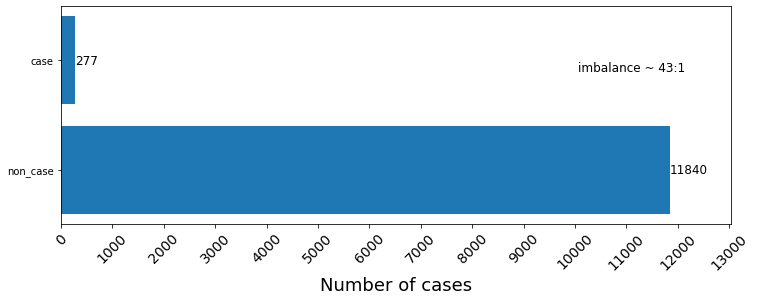

In [19]:
plot_imbalance(dataset)

In [20]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [21]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:15 || ##
Year: 2011 || w0:1, w1:17 || ##
Year: 2012 || w0:1, w1:18 || ##
Year: 2013 || w0:1, w1:17 || ##
Year: 2014 || w0:1, w1:15 || ##
Year: 2015 || w0:1, w1:15 || ##
Year: 2016 || w0:1, w1:15 || ##
Year: 2017 || w0:1, w1:15 || ##
Year: 2018 || w0:1, w1:30 || ##
Year: 2019 || w0:1, w1:16 || ##
Year: 2020 || w0:1, w1:15 || ##
Year: 2021 || w0:1, w1:15 || ##
Year: 2022 || w0:1, w1:15 || ##


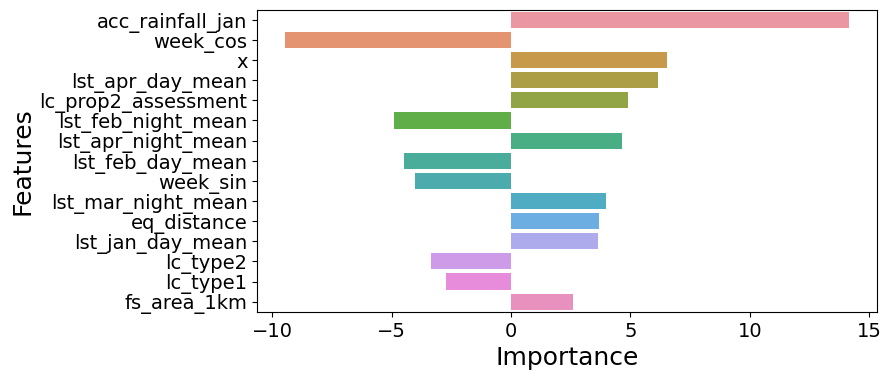

In [22]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

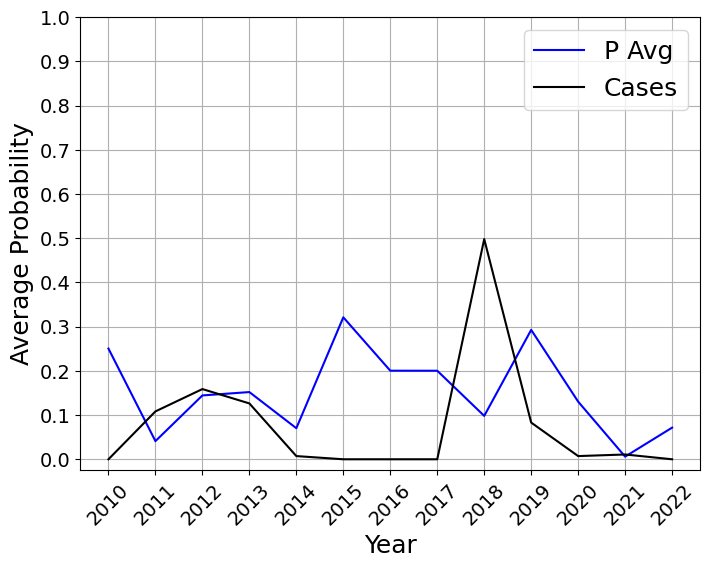

In [23]:
plot_trend_curve(results_test, list(dsc['case']))

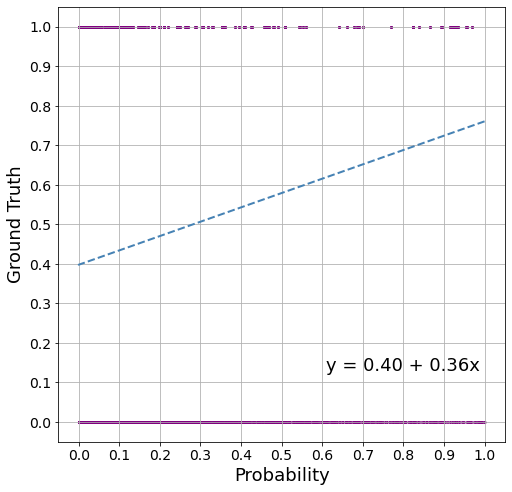

In [24]:
plot_probability_curve(results_test)

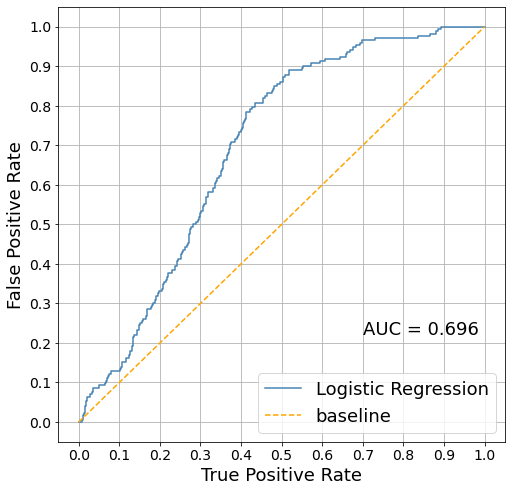

In [25]:
plot_roc_curve(results_test)

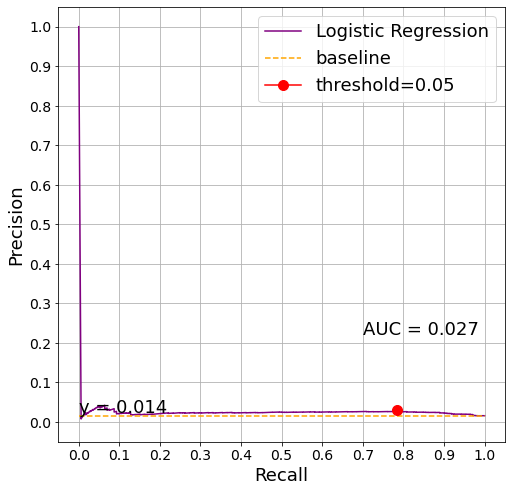

In [26]:
plot_pr_curve(results_test, plot_fbeta=True)

In [27]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 9.35%
Weighted Average: 9.60%


In [28]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/05/2010,0,0,0,NaN,NaN
1,16/05/2010,0,0,0,NaN,NaN
2,01/06/2010,0,0,0,NaN,NaN
3,16/06/2010,0,0,0,NaN,NaN
4,01/07/2010,0,0,0,NaN,NaN
...,...,...,...,...,...,...
177,16/09/2022,0,0,0,NaN,NaN
178,01/10/2022,0,0,0,NaN,NaN
179,16/10/2022,0,0,0,NaN,NaN
180,01/11/2022,0,0,0,NaN,NaN


In [29]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,0,0,0,nan %,NaN
1,2011,21,10,21,47.62 %,0.4762
2,2012,21,0,17,0.00 %,0.0000
3,2013,28,1,23,4.35 %,0.0435
4,2014,2,0,2,0.00 %,0.0000
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,80,1,35,2.86 %,0.0286
9,2019,15,3,15,20.00 %,0.2000


In [30]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [31]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,0.0000,0.4989,0.5011,0.0000,0.0000,0.0000,0.4527
1,2011,21.0000,0.1136,0.7342,0.1143,0.5714,0.4626,0.1264
2,2012,21.0000,0.3377,0.5952,0.0353,0.5238,0.2886,0.2760
3,2013,28.0000,0.3766,0.7478,0.0690,0.8571,0.5126,0.2560
4,2014,2.0000,0.1981,0.9018,0.0109,1.0000,0.1581,0.1168
5,2015,0.0000,0.5693,0.4307,0.0000,0.0000,0.0000,0.6708
6,2016,0.0000,0.4426,0.5574,0.0000,0.0000,0.0000,0.3208
7,2017,0.0000,0.4286,0.5714,0.0000,0.0000,0.0000,0.3364
8,2018,80.0000,0.2273,0.6151,0.1667,0.4375,0.3993,0.3965
9,2019,15.0000,0.5206,0.7098,0.0291,0.9333,0.3301,0.6370


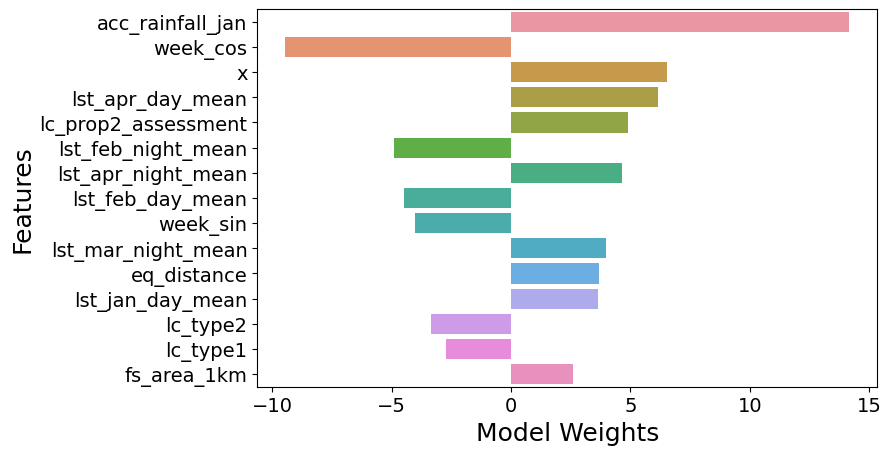

In [32]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [33]:
results_test[results_test['year'] == 2022].head(30)

,x,y,municipality,day,month,year,case,probability
25,23.47721,37.48420,πορου,1,8,2022,0,0.993052
35,23.47721,37.48420,πορου,16,7,2022,0,0.989905
62,23.47721,37.48420,πορου,1,7,2022,0,0.980111
116,23.47721,37.48420,πορου,1,9,2022,0,0.957437
118,23.47721,37.48420,πορου,16,8,2022,0,0.956711
126,23.47721,37.48420,πορου,16,9,2022,0,0.952452
180,23.47721,37.48420,πορου,16,10,2022,0,0.927792
357,23.47721,37.48420,πορου,16,6,2022,0,0.856980
476,23.47721,37.48420,πορου,1,10,2022,0,0.814514
701,23.98322,37.87562,μαρκοπουλου μεσογαιας,1,8,2022,0,0.727168
